**Home assignment 5**

**Team Members**


*   Sandeep Hidellarachchi - 100008335
*   Kevin Luke Prashanth - 100008184


*   Manikanta, Engalliji - 100008155





# Import the Libraries

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm

# Import the dataset

In [56]:
df = pd.read_csv('insurance.csv')
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [57]:
df = pd.read_csv('insurance.csv')

charges = df['charges']

# Data Cleaning

In [58]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


# Selecting the Charges column for the assignment

In [59]:
charges_data = df[['charges']].copy()
charges_data.head(20)

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
6,8240.58960
7,7281.50560
8,6406.41070
9,28923.13692


# Descriptive Statistics

In [60]:
# Calculat the mean of the charges column
mean_charges = charges_data['charges'].mean()

# Display the results
print('Mean of charges:', mean_charges)

Mean of charges: 13270.422265141257


In [61]:
# Calculate the Median of the charges
median_charges = charges_data['charges'].median()

# Display the result
print('Median of charges:', median_charges)

Median of charges: 9382.033


In [62]:
# Calculate the Mode of the charges
Mode_charges = charges_data['charges'].mode()

# Display the result
print('Median of charges:', Mode_charges)

Median of charges: 0    1639.5631
Name: charges, dtype: float64


In [63]:
# Calculate the Min of the charges
min_charges = charges_data['charges'].min()

# Display the result
print('Min of charges:', min_charges)

Min of charges: 1121.8739


In [64]:
# Calculate the Max of the charges
max_charges = charges_data['charges'].max()

# Display the result
print('Max of charges:', max_charges)

Max of charges: 63770.42801


In [65]:
# Calculate the Range of the charges
range_charges = max_charges - min_charges

# Display the result
print('Range of charges:', range_charges)

Range of charges: 62648.554110000005


In [66]:
# Calculate the Variance of the charges
variance_charges = charges_data['charges'].var()

# Display the result
print('Variance of charges:', variance_charges)

Variance of charges: 146652372.1528548


In [67]:
# Calculate the Standard Deviation of the charges
std_charges = charges_data['charges'].std()

# Display the result
print('Standard Deviation of charges:', std_charges)

Standard Deviation of charges: 12110.011236693994


In [68]:
# Calculate the Skewness of the charges
Skewness_charges = charges_data['charges'].skew()

# Display the result
print('Skewness of charges:', Skewness_charges)

# close to 0 -> roughly symetric
# positive - > right skewed with longer tail on the right
# negative -> left skewed with longer tail on the left

Skewness of charges: 1.5158796580240388


In [69]:
# Calculate the Kurtosis of the charges
kurtosis_charges = charges_data['charges'].kurt()

# Display the result
print('Kurtosis of charges:', kurtosis_charges)

# close to 0 -> similar tail heaviness to normal distribution
# positive - > Heavier tail / more extreme values than normal
# negative -> Lighter tails / fewer extreme values than normal

Kurtosis of charges: 1.6062986532967907


In [70]:
# Calculate the Quartiles of the charges
q1_charges = charges_data['charges'].quantile(0.25)
q2_charges = charges_data['charges'].quantile(0.50)
q3_charges = charges_data['charges'].quantile(0.75)

# Display the results
print('Q1 (25th percentile):', q1_charges)
print('Q2 (50th percentile / Median):', q2_charges)
print('Q3 (75th percentile):', q3_charges)

Q1 (25th percentile): 4740.28715
Q2 (50th percentile / Median): 9382.033
Q3 (75th percentile): 16639.912515


In [71]:
charges_data.describe()

,charges
count,1338.000000
mean,13270.422265
std,12110.011237
min,1121.873900
25%,4740.287150
50%,9382.033000
75%,16639.912515
max,63770.428010


# Section 3: Exploratory Data Visualization




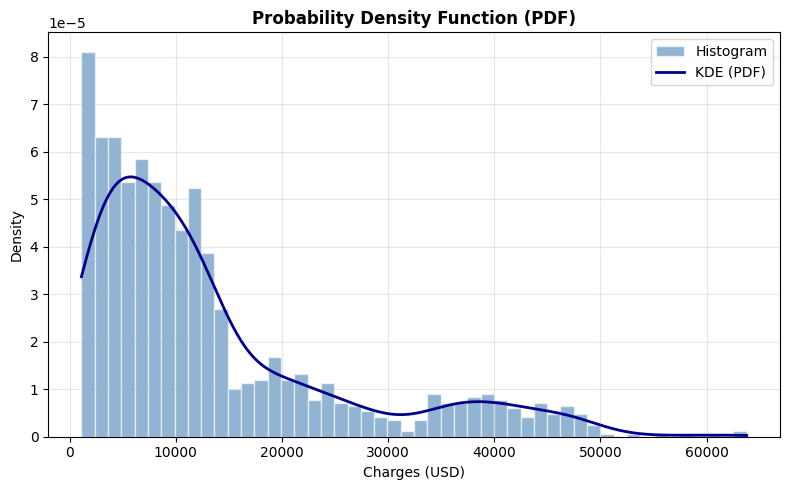

In [72]:
# ═══════════════════════════════════════════════════════════
# FIGURE 1: PDF — Probability Density Function
# ═══════════════════════════════════════════════════════════

x = np.linspace(charges.min(), charges.max(), 500)

plt.figure(figsize=(8, 5))

plt.hist(
    charges,
    bins=50,
    density=True,
    color='steelblue',
    alpha=0.6,
    edgecolor='white',
    label='Histogram'
)

kde = stats.gaussian_kde(charges)
plt.plot(x, kde(x), color='darkblue', lw=2, label='KDE (PDF)')

plt.title('Probability Density Function (PDF)', fontweight='bold')
plt.xlabel('Charges (USD)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_pdf.png', dpi=150, bbox_inches='tight')
plt.show()

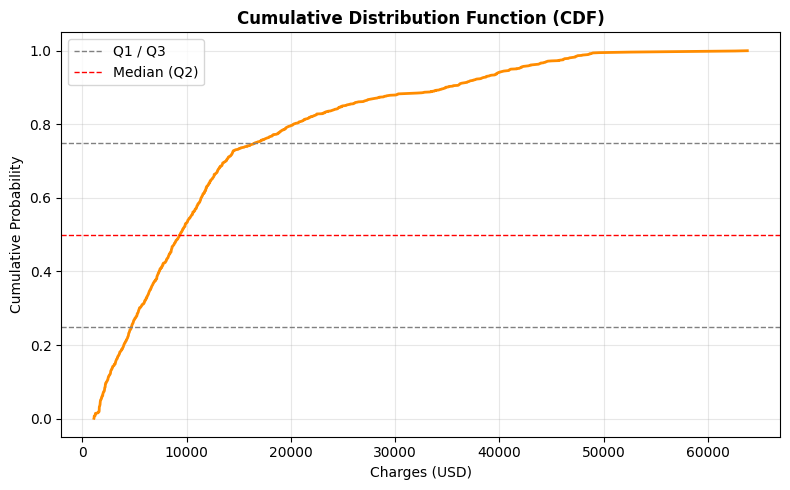

In [73]:
# ═══════════════════════════════════════════════════════════
# FIGURE 2: CDF — Cumulative Distribution Function
# ═══════════════════════════════════════════════════════════

plt.figure(figsize=(8, 5))

sorted_charges = np.sort(charges)
ecdf = np.arange(1, len(sorted_charges) + 1) / len(sorted_charges)

plt.plot(sorted_charges, ecdf, color='darkorange', lw=2)

plt.axhline(0.25, color='gray', ls='--', lw=1, label='Q1 / Q3')
plt.axhline(0.75, color='gray', ls='--', lw=1)
plt.axhline(0.50, color='red',  ls='--', lw=1, label='Median (Q2)')

plt.title('Cumulative Distribution Function (CDF)', fontweight='bold')
plt.xlabel('Charges (USD)')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_cdf.png', dpi=150, bbox_inches='tight')
plt.show()

In [74]:
# Calculate Q1 and Q3
q1 = charges.quantile(0.25)
q3 = charges.quantile(0.75)

# Calculate the Interquartile Range (IQR)
iqr = q3 - q1

# Calculate the lower and upper bounds for detecting outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify outliers
outliers = charges[(charges < lower_bound) | (charges > upper_bound)]

# Display the outlier information
print("Lower bound for outliers:", lower_bound)
print("Upper bound for outliers:", upper_bound)
print("Number of outliers:", len(outliers))

Lower bound for outliers: -13109.1508975
Upper bound for outliers: 34489.350562499996
Number of outliers: 139


# Section 4: Fit Three Continuous Probability Distributions

Goodness of Fit — MSE (×10⁻⁸):
  Normal:      0.0257
  Exponential: 0.0042
  Uniform:     0.0444

→ Exponential has the lowest MSE → best fit among the three


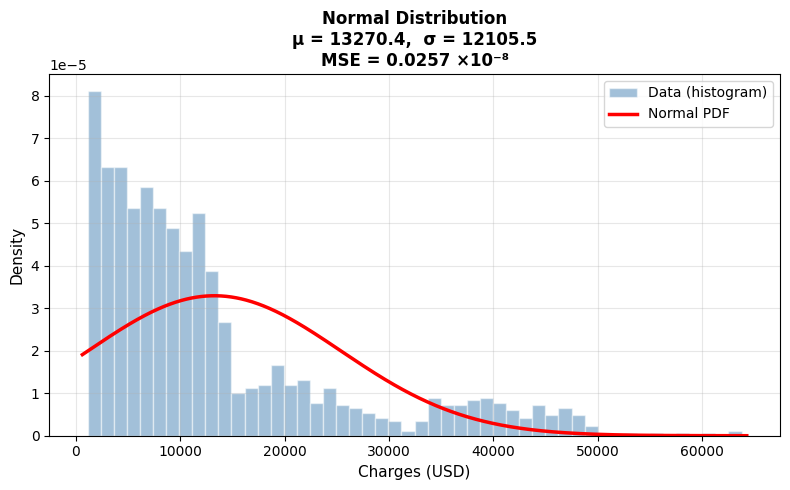

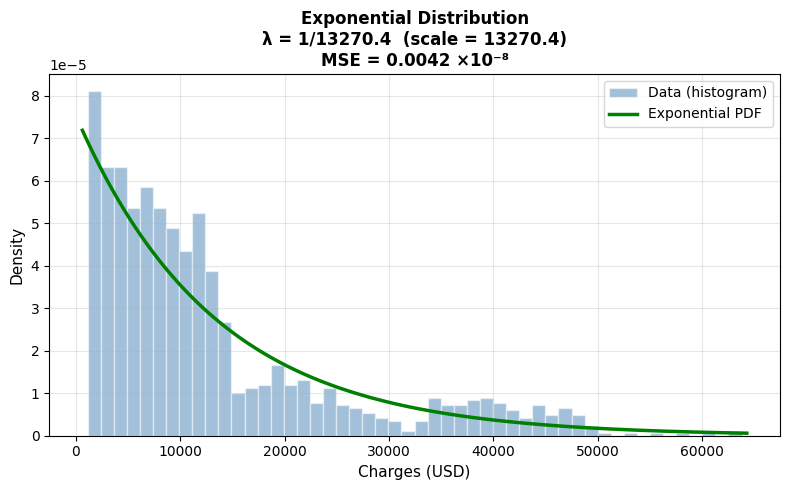

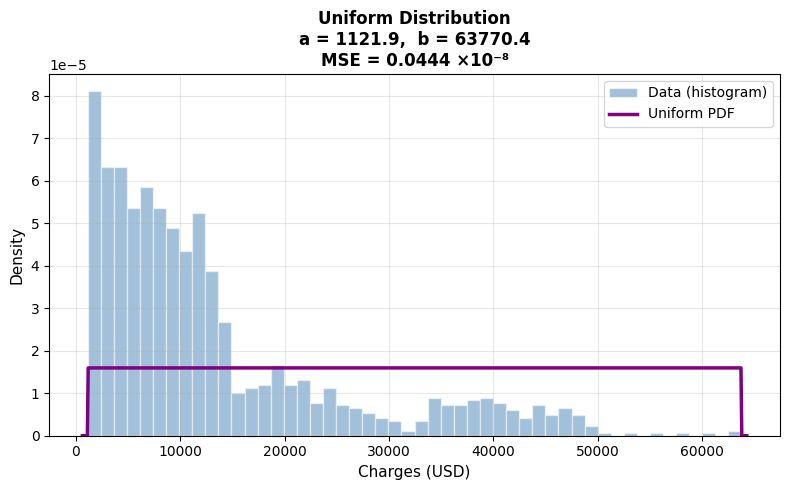

In [75]:
# Normal: returns mu (mean) and sigma (std deviation)
mu, sigma = stats.norm.fit(charges)

# Exponential: floc=0 fixes start at 0, returns scale (= 1/λ)
ex_loc, ex_scale = stats.expon.fit(charges, floc=0)

# Uniform: returns loc (minimum) and scale (range = max - min)
un_loc, un_scale = stats.uniform.fit(charges)

# ─────────────────────────────────────────────
# STEP 2: COMPUTE MSE — GOODNESS OF FIT
#
# IDEA:
#   The histogram gives us the actual density at each bin.
#   The PDF gives us the predicted density at each bin.
#   MSE = average of (actual - predicted)² across all bins.
#   Lower MSE → the PDF curve is closer to the histogram → better fit.
# ─────────────────────────────────────────────

# Build the histogram with 50 bins, normalised to density
# counts = actual density value at each bin
# bin_edges = the left/right boundary of each bin
counts, bin_edges = np.histogram(charges, bins=50, density=True)

# Compute the centre of each bin
# This is where we evaluate the PDF to compare against the histogram
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Evaluate each fitted PDF at the bin centres
pdf_norm  = stats.norm.pdf(bin_centers, mu, sigma)
pdf_expon = stats.expon.pdf(bin_centers, ex_loc, ex_scale)
pdf_unif  = stats.uniform.pdf(bin_centers, un_loc, un_scale)

# MSE formula: mean of (actual density - predicted density)²
# Multiplied by 1e8 to convert tiny scientific notation values
# into readable numbers for display (×10⁻⁸)
mse_norm  = np.mean((counts - pdf_norm)  ** 2) * 1e8
mse_expon = np.mean((counts - pdf_expon) ** 2) * 1e8
mse_unif  = np.mean((counts - pdf_unif)  ** 2) * 1e8

print("Goodness of Fit — MSE (×10⁻⁸):")
print(f"  Normal:      {mse_norm:.4f}")
print(f"  Exponential: {mse_expon:.4f}")
print(f"  Uniform:     {mse_unif:.4f}")
print(f"\n→ Exponential has the lowest MSE → best fit among the three")

# ─────────────────────────────────────────────
# STEP 3: x-AXIS VALUES FOR SMOOTH PDF CURVES
# ─────────────────────────────────────────────

x_plot = np.linspace(charges.min() - 500, charges.max() + 500, 800)

# ─────────────────────────────────────────────
# STEP 4: PLOT — one figure per distribution
# Each figure: histogram + fitted PDF + MSE in title
# ─────────────────────────────────────────────

# Bundle all three into a list to loop cleanly
configs = [
    (
        'Normal',
        stats.norm.pdf(x_plot, mu, sigma),
        'red',
        f'μ = {mu:.1f},  σ = {sigma:.1f}',
        mse_norm,
        'fig2_normal_fit.png'
    ),
    (
        'Exponential',
        stats.expon.pdf(x_plot, ex_loc, ex_scale),
        'green',
        f'λ = 1/{ex_scale:.1f}  (scale = {ex_scale:.1f})',
        mse_expon,
        'fig2_exponential_fit.png'
    ),
    (
        'Uniform',
        stats.uniform.pdf(x_plot, un_loc, un_scale),
        'purple',
        f'a = {un_loc:.1f},  b = {un_loc + un_scale:.1f}',
        mse_unif,
        'fig2_uniform_fit.png'
    ),
]

for dist_name, pdf_curve, color, params_txt, mse, fname in configs:

    plt.figure(figsize=(8, 5))

    # Histogram of actual data
    plt.hist(charges, bins=50, density=True,
             color='steelblue', alpha=0.5, edgecolor='white',
             label='Data (histogram)')

    # Fitted PDF curve overlaid on histogram
    plt.plot(x_plot, pdf_curve, color=color, lw=2.5,
             label=f'{dist_name} PDF')

    # Title includes parameters + MSE so the goodness of fit is visible
    plt.title(
        f'{dist_name} Distribution\n{params_txt}\nMSE = {mse:.4f} ×10⁻⁸',
        fontsize=12, fontweight='bold'
    )
    plt.xlabel('Charges (USD)', fontsize=11)
    plt.ylabel('Density', fontsize=11)
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

# Section 5: Q-Q Plot Analysis

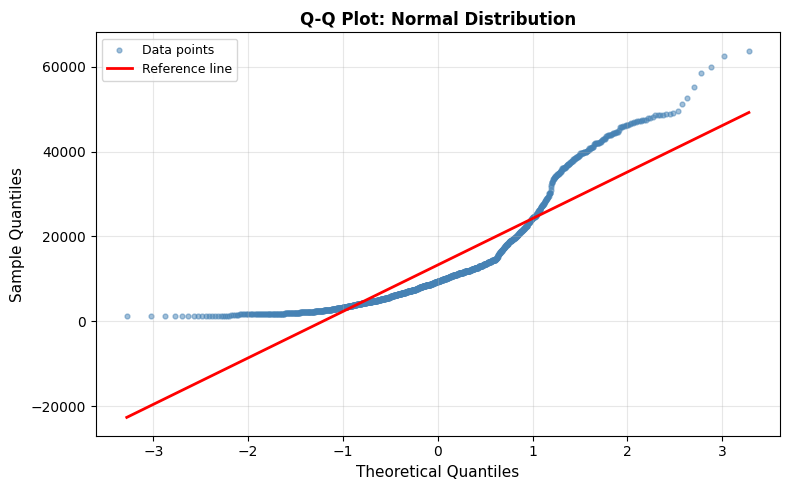

In [76]:
# ═══════════════════════════════════════════════════════════
# FIGURE 1: Normal Q-Q Plot
# ═══════════════════════════════════════════════════════════

(osm, osr), (slope, intercept, r) = stats.probplot(charges, dist='norm')

plt.figure(figsize=(8, 5))

plt.scatter(osm, osr,
            color='steelblue', alpha=0.5, s=12, label='Data points')

plt.plot(osm, np.array(osm) * slope + intercept,
         color='red', lw=2, label='Reference line')

plt.title('Q-Q Plot: Normal Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Theoretical Quantiles', fontsize=11)
plt.ylabel('Sample Quantiles', fontsize=11)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_qq_normal.png', dpi=150, bbox_inches='tight')
plt.show()

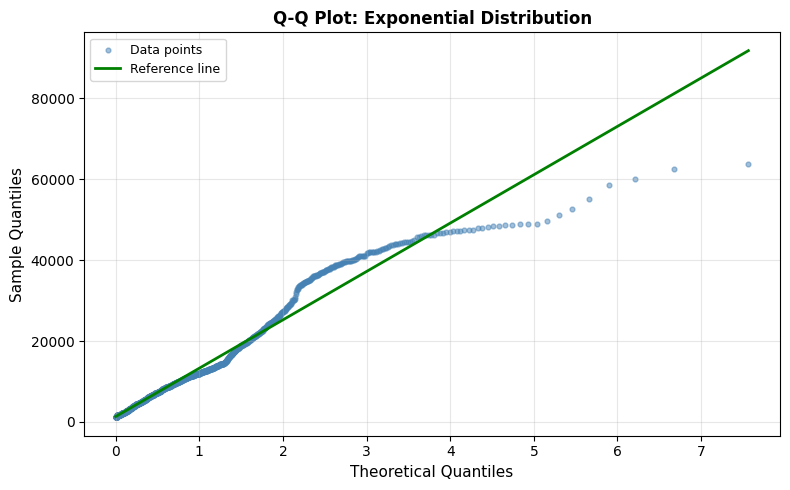

In [77]:
# ═══════════════════════════════════════════════════════════
# FIGURE 2: Exponential Q-Q Plot
# ═══════════════════════════════════════════════════════════

(osm2, osr2), (slope2, intercept2, r2) = stats.probplot(charges, dist='expon')

plt.figure(figsize=(8, 5))

plt.scatter(osm2, osr2,
            color='steelblue', alpha=0.5, s=12, label='Data points')

plt.plot(osm2, np.array(osm2) * slope2 + intercept2,
         color='green', lw=2, label='Reference line')

plt.title('Q-Q Plot: Exponential Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Theoretical Quantiles', fontsize=11)
plt.ylabel('Sample Quantiles', fontsize=11)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_qq_exponential.png', dpi=150, bbox_inches='tight')
plt.show()

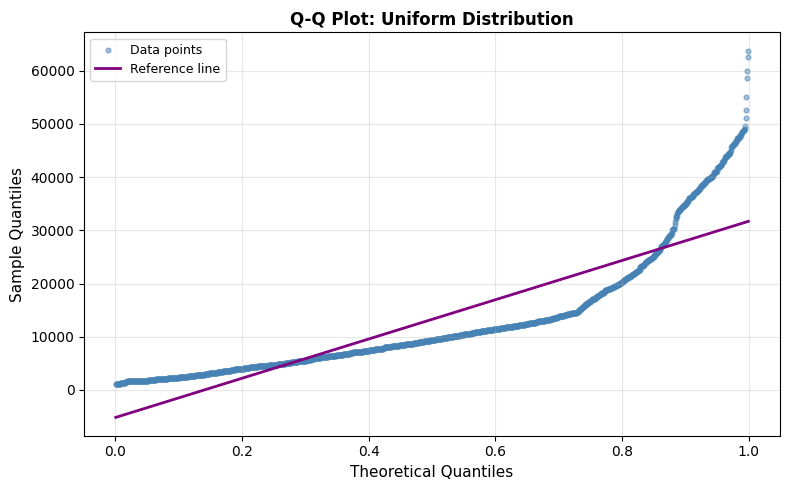

In [78]:
# ═══════════════════════════════════════════════════════════
# FIGURE 3: Uniform Q-Q Plot
# ═══════════════════════════════════════════════════════════

(osm3, osr3), (slope3, intercept3, r3) = stats.probplot(charges, dist='uniform')

plt.figure(figsize=(8, 5))

plt.scatter(osm3, osr3,
            color='steelblue', alpha=0.5, s=12, label='Data points')

plt.plot(osm3, np.array(osm3) * slope3 + intercept3,
         color='purple', lw=2, label='Reference line')

plt.title('Q-Q Plot: Uniform Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Theoretical Quantiles', fontsize=11)
plt.ylabel('Sample Quantiles', fontsize=11)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_qq_uniform.png', dpi=150, bbox_inches='tight')
plt.show()

# Section 6: Demonstrate the Central Limit Theorem (CLT)

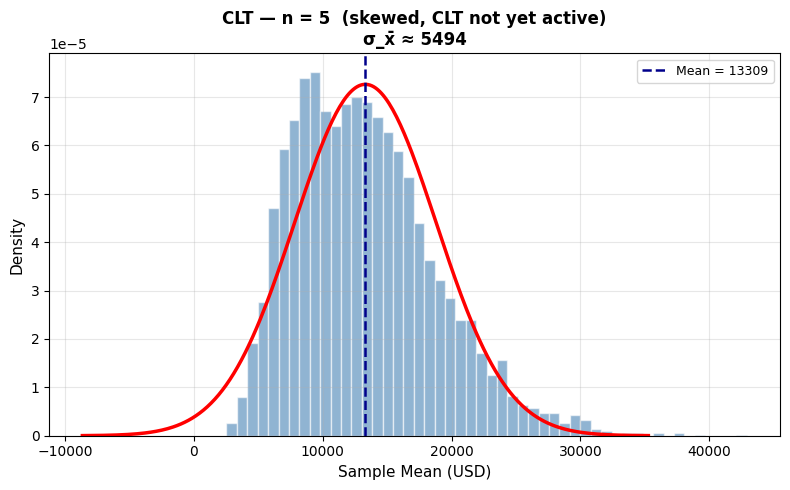

In [79]:
sample_sizes = [5, 30, 300]

n_simulations = 5000
np.random.seed(42)

# ═══════════════════════════════════════════════════════════
# FIGURE 1: n = 5  (skewed, CLT not yet active)
# ═══════════════════════════════════════════════════════════

n = 5
sample_means = [
    np.random.choice(charges, size=n, replace=True).mean()
    for _ in range(n_simulations)
]
mu_hat    = np.mean(sample_means)
sigma_hat = np.std(sample_means)

plt.figure(figsize=(8, 5))

plt.hist(sample_means, bins=50, density=True,
         color='steelblue', alpha=0.6, edgecolor='white')

x_range = np.linspace(mu_hat - 4 * sigma_hat, mu_hat + 4 * sigma_hat, 300)
plt.plot(x_range, norm.pdf(x_range, mu_hat, sigma_hat),
         color='red', lw=2.5)

plt.axvline(mu_hat, color='darkblue', ls='--', lw=1.8,
            label=f'Mean = {mu_hat:.0f}')

plt.title(f'CLT — n = {n}  (skewed, CLT not yet active)\nσ_x̄ ≈ {sigma_hat:.0f}',
          fontsize=12, fontweight='bold')
plt.xlabel('Sample Mean (USD)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_clt_n5.png', dpi=150, bbox_inches='tight')
plt.show()

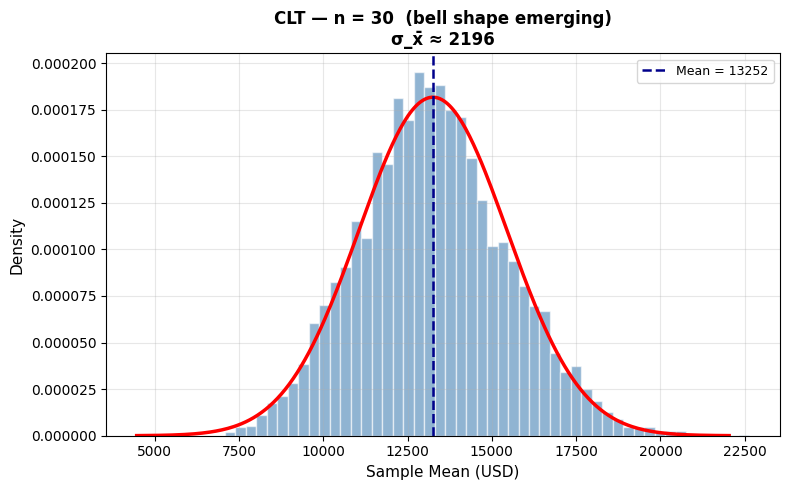

In [80]:
# ═══════════════════════════════════════════════════════════
# FIGURE 2: n = 30  (bell shape emerging)
# ═══════════════════════════════════════════════════════════

n = 30
sample_means = [
    np.random.choice(charges, size=n, replace=True).mean()
    for _ in range(n_simulations)
]
mu_hat    = np.mean(sample_means)
sigma_hat = np.std(sample_means)

plt.figure(figsize=(8, 5))

plt.hist(sample_means, bins=50, density=True,
         color='steelblue', alpha=0.6, edgecolor='white')

x_range = np.linspace(mu_hat - 4 * sigma_hat, mu_hat + 4 * sigma_hat, 300)
plt.plot(x_range, norm.pdf(x_range, mu_hat, sigma_hat),
         color='red', lw=2.5)

plt.axvline(mu_hat, color='darkblue', ls='--', lw=1.8,
            label=f'Mean = {mu_hat:.0f}')

plt.title(f'CLT — n = {n}  (bell shape emerging)\nσ_x̄ ≈ {sigma_hat:.0f}',
          fontsize=12, fontweight='bold')
plt.xlabel('Sample Mean (USD)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_clt_n30.png', dpi=150, bbox_inches='tight')
plt.show()

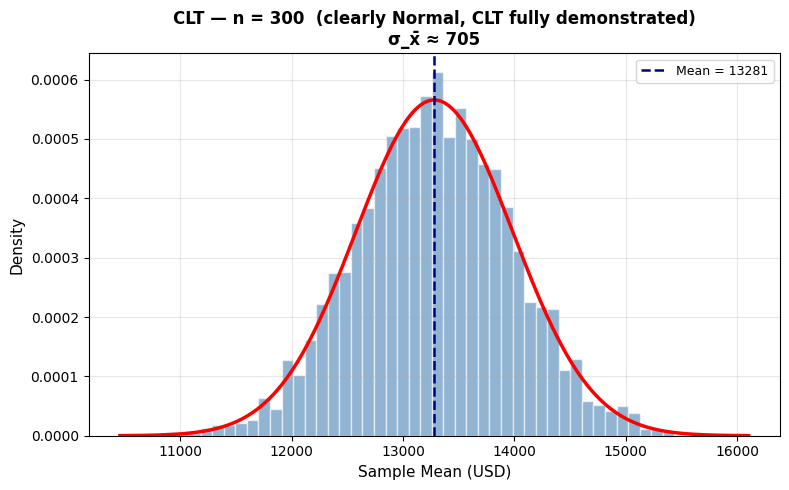

In [81]:
# ═══════════════════════════════════════════════════════════
# FIGURE 3: n = 300  (CLT fully demonstrated)
# ═══════════════════════════════════════════════════════════

n = 300
sample_means = [
    np.random.choice(charges, size=n, replace=True).mean()
    for _ in range(n_simulations)
]
mu_hat    = np.mean(sample_means)
sigma_hat = np.std(sample_means)

plt.figure(figsize=(8, 5))

plt.hist(sample_means, bins=50, density=True,
         color='steelblue', alpha=0.6, edgecolor='white')

x_range = np.linspace(mu_hat - 4 * sigma_hat, mu_hat + 4 * sigma_hat, 300)
plt.plot(x_range, norm.pdf(x_range, mu_hat, sigma_hat),
         color='red', lw=2.5)

plt.axvline(mu_hat, color='darkblue', ls='--', lw=1.8,
            label=f'Mean = {mu_hat:.0f}')

plt.title(f'CLT — n = {n}  (clearly Normal, CLT fully demonstrated)\nσ_x̄ ≈ {sigma_hat:.0f}',
          fontsize=12, fontweight='bold')
plt.xlabel('Sample Mean (USD)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_clt_n300.png', dpi=150, bbox_inches='tight')
plt.show()